First lets clean the desired dataset.

In [2]:
#import packages and run 

import pandas as pd

df = pd.read_excel("datadotgov_ais20.xlsx")

df.shape
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51386 entries, 0 to 51385
Data columns (total 93 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   abn                                                                            51386 non-null  int64  
 1   charity name                                                                   51386 non-null  object 
 2   registration status                                                            51386 non-null  object 
 3   charity website                                                                34565 non-null  object 
 4   charity size                                                                   51380 non-null  object 
 5   basic religious charity                                                        51386 non-null  object 
 6   ais due date          

In [3]:
#clean columns

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)  # replaces ALL non-alphanumeric chars
)

#filter to valid charities

df = df[df["registration_status"] == "Registered"]
df = df[df["charity_size"].notna()]

In [4]:
#checking...

print(df.columns.tolist())

['abn', 'charity_name', 'registration_status', 'charity_website', 'charity_size', 'basic_religious_charity', 'ais_due_date', 'date_ais_received', 'financial_report_date_received', 'conducted_activities', 'why_charity_did_not_conduct_activities', 'international_activities_details', 'international_activities_undertaken_transferring_goods_or_services_overseas', 'international_activities_undertaken_operating_overseas_including_programs', 'other_international_activities', 'other_international_activities_description', 'how_purposes_were_pursued', 'staff_full_time', 'staff_part_time', 'staff_casual', 'total_full_time_equivalent_staff', 'staff_volunteers', 'cash_or_accrual', 'type_of_financial_statement', 'report_consolidated_with_more_than_one_entity', 'charity_report_has_a_modification', 'type_of_report_modification', 'charity_has_related_party_transactions', 'charity_has_documented_policies_for_related_party_transactions', 'fin_report_from', 'fin_report_to', 'revenue_from_government', 'dona

In [5]:
# Slices from index 0 up to (but not including) index 10
print(df[:10])

           abn                                       charity_name  \
0  11000047950                  Sydney Missionary & Bible College   
1  11000073870                                Integricare Limited   
2  11000761571                    AUSTRALIANS IN MISSION TOGETHER   
3  11001233790  The Greek Orthodox Church & Community Of The H...   
4  11001241005                       Wangarang Industries Limited   
5  11001350867                                    Subud Australia   
6  11001794396                    Bethel Christian School Limited   
7  11001832828         PACIFIC GROUP OF CHRISTIAN SCHOOLS LIMITED   
8  11002058127                      Burrum Benevolent Society Inc   
9  11002389746                           St Peters Pre-School Ltd   

  registration_status                       charity_website charity_size  \
0          Registered                       www.smbc.edu.au        Large   
1          Registered                www.integricare.org.au        Large   
2          R

In [6]:
#convert numeric columns

numeric_cols = [
    "staff_full_time",
    "staff_part_time",
    "staff_volunteers",
    "total_full_time_equivalent_staff",
    "total_revenue",
    "total_expenses",
    "net_surplus_deficit"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
#handle null values

count_cols = [
    "staff_full_time",
    "staff_part_time",
    "staff_volunteers"
]

df[count_cols] = df[count_cols].fillna(0)

#now for the financial values
df = df[df["total_revenue"].notna()]
df = df[df["total_expenses"].notna()]

In [8]:
#remove outliers

df = df[df["total_revenue"] > 0]
df = df[df["total_expenses"] > 0]
df = df[df["total_revenue"] < df["total_revenue"].quantile(0.99)]

In [9]:
#creating core features

df["total_staff"] = df["staff_full_time"] + df["staff_part_time"]
df["profit_margin"] = df["net_surplus_deficit"] / df["total_revenue"]
df["revenue_per_staff"] = df["total_revenue"] / (df["total_staff"] + 1)
df["revenue_per_staff"] = df["total_revenue"] / (df["total_staff"] + 1)

In [10]:
#sanity check

df.describe()
df.isnull().sum().sort_values(ascending=False)

association_number_nt                             34828
other_international_activities_description        34673
fundraising_number_act                            34660
why_charity_did_not_conduct_activities            34546
association_number_act                            34521
                                                  ...  
grants_and_donations_made_for_use_in_australia        0
interest_expenses                                     0
employee_expenses                                     0
total_gross_income                                    0
revenue_per_staff                                     0
Length: 96, dtype: int64

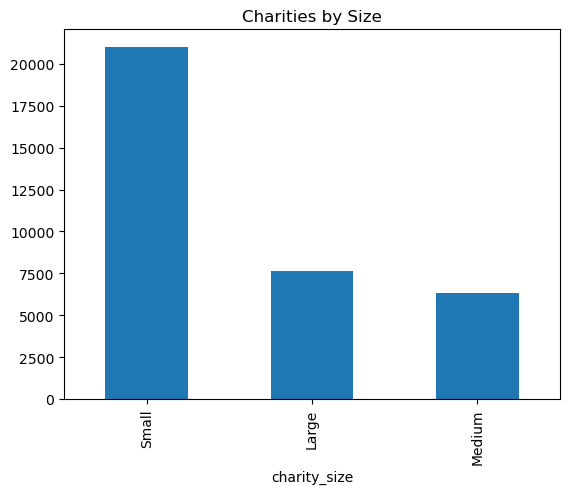

In [11]:
#quick EDA

import matplotlib.pyplot as plt

df["charity_size"].value_counts().plot(kind="bar")
plt.title("Charities by Size")
plt.show()

I found a dataset on programs that I think would go super well with this. Let's try it.

In [67]:
#adding dataset

programs = pd.read_excel("datadotgov_ais20_programs.xlsx")

print(programs.columns.tolist())
programs.head()
programs.info()

['ABN', 'Charity Name', 'Registration Status', 'Program name', 'Classification', 'Children - aged 6 to under 15', 'Environment', 'Families', 'General community in Australia', 'Migrants, refugees or asylum seekers', 'Overseas communities or charities', 'Aboriginal and Torres Strait Islander people', 'Adults - aged 65 and over', 'Early childhood - aged under 6', 'Females', 'Gay, lesbian, bisexual, transgender or intersex persons', 'Males', 'People at risk of homelessness/ people experiencing homelessness', 'People with disabilities', 'Victims of crime (including family violence)', 'Animals', 'Financially disadvantaged people', 'People in rural/regional/remote communities', 'People with chronic illness (including terminal illness)', 'Pre/post release offenders and/or their families', 'Veterans and/or their families', 'Youth - 15 to under 25', 'Adults - aged 25 to under 65', 'Other charities', 'People from a culturally and linguistically diverse background', 'Unemployed persons', 'Victims 

In [68]:
#clean column names

programs.columns = (
    programs.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
)

print(programs.columns.tolist())

['abn', 'charity_name', 'registration_status', 'program_name', 'classification', 'children_aged_6_to_under_15', 'environment', 'families', 'general_community_in_australia', 'migrants_refugees_or_asylum_seekers', 'overseas_communities_or_charities', 'aboriginal_and_torres_strait_islander_people', 'adults_aged_65_and_over', 'early_childhood_aged_under_6', 'females', 'gay_lesbian_bisexual_transgender_or_intersex_persons', 'males', 'people_at_risk_of_homelessness_people_experiencing_homelessness', 'people_with_disabilities', 'victims_of_crime_including_family_violence_', 'animals', 'financially_disadvantaged_people', 'people_in_rural_regional_remote_communities', 'people_with_chronic_illness_including_terminal_illness_', 'pre_post_release_offenders_and_or_their_families', 'veterans_and_or_their_families', 'youth_15_to_under_25', 'adults_aged_25_to_under_65', 'other_charities', 'people_from_a_culturally_and_linguistically_diverse_background', 'unemployed_persons', 'victims_of_disaster', 'ot

In [73]:
#now lets drill down those category columns into something numerical. keep only the columns we need for the programs feature set

base_cols = ["abn", "charity_name", "classification"]

category_cols = [col for col in programs.columns if col not in base_cols]

programs = programs[base_cols + category_cols].copy()

#clean too

programs["abn"] = programs["abn"].astype(str).str.strip()
programs["charity_name"] = programs["charity_name"].astype(str).str.strip()
programs["classification"] = programs["classification"].astype(str).str.strip()

In [75]:
#convert category flags to binary
#Y = 1, everything else = 0

programs[category_cols] = programs[category_cols].apply(
    lambda x: x.astype(str).str.strip().str.upper().eq("Y").astype(int)
)

In [77]:
#program count = number of program rows per ABN

program_count = (
    programs.groupby("abn")
    .size()
    .reset_index(name="program_count")
)

In [79]:
#build category coverage at the ABN level
#max() makes each category count once per charity, even if multiple programs have Y

programs_binary = (
    programs.groupby("abn")[category_cols]
    .max()
    .reset_index()
)

In [81]:
#category count = number of unique categories covered by the charity

programs_binary["category_count"] = programs_binary[category_cols].sum(axis=1)

In [83]:
#I feel like these columns would be useful for specific populations that may need it. select vulnerable population columns

high_need_keywords = [
    "disadvantaged",
    "disabilities",
    "homeless",
    "victim",
    "unemployed",
    "refugee",
    "aboriginal"
]

high_need_cols = [
    col for col in category_cols
    if any(k in col for k in high_need_keywords)
]

print(high_need_cols)

['migrants_refugees_or_asylum_seekers', 'aboriginal_and_torres_strait_islander_people', 'people_at_risk_of_homelessness_people_experiencing_homelessness', 'people_with_disabilities', 'victims_of_crime_including_family_violence_', 'financially_disadvantaged_people', 'unemployed_persons', 'victims_of_disaster']


In [85]:
#vulnerability score = number of unique high-need categories covered by the charity

programs_binary["vulnerability_score"] = programs_binary[high_need_cols].sum(axis=1)

In [87]:
#get charity-level text fields

programs_base = (
    programs.groupby("abn", as_index=False)
    .agg({
        "charity_name": "first",
        "classification": "first"
    })
)

In [89]:
#combine into final programs features dataset

programs_agg = (
    programs_base
    .merge(program_count, on="abn", how="left")
    .merge(
        programs_binary[["abn", "category_count", "vulnerability_score"]],
        on="abn",
        how="left"
    )
)

In [22]:
df.to_csv("clean_charity_data.csv", index=False)
programs_agg.to_csv("programs_features.csv", index=False)

In [91]:
#average vulnerability per program

programs_agg["avg_vulnerability"] = (
    programs_agg["vulnerability_score"] / programs_agg["program_count"]
)

In [93]:
#final validation

programs_agg.head()
programs_agg.describe(include="all")
programs_agg.sort_values("program_count", ascending=False).head()
programs_agg.sort_values("category_count", ascending=False).head()
programs_agg.sort_values("vulnerability_score", ascending=False).head()

,abn,charity_name,classification,program_count,category_count,vulnerability_score,avg_vulnerability
28395,63811472602,St Thomas the Apostle Catholic Parish Clyde North,Catholicism,1,25,8,8.0
40536,86446474706,Laidley District Historical Society Inc,Arts and culture,2,28,8,4.0
24135,55749101637,St Gabriels Catholic Church Reservoir,Catholicism,1,24,8,8.0
24129,55736308416,St Patricks Catholic Church Lilydale,Catholicism,1,24,8,8.0
24115,55707852786,St Joseph's Catholic Church - Foster,Catholicism,1,25,8,8.0


In [95]:
#export final files separately for Alteryx join

df.to_csv("clean_charity_data.csv", index=False)
programs_agg.to_csv("programs_features.csv", index=False)